# Playground

In [29]:
from typing import Tuple
from functools import reduce
from collections import Counter

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T

import numpy as np
import matplotlib.pyplot as plt
import PIL

In [2]:
torch.manual_seed(71)

## Collections.Counter

In [12]:
counter = Counter()
counter.update(['a', 'b', 'b', 'c', 'c', 'c'])
print(counter)

Counter({'c': 3, 'b': 2, 'a': 1})


## Tests avec String

In [7]:
print("test".rjust(10, " "))
print("test".ljust(10, " "))
print(("abc"*40).ljust(10, " ")[:30])

      test
test      
abcabcabcabcabcabcabcabcabcabc


## Tests sur l'indexation des tenseurs 

### Tenseur comme indice utilisé avec un autre tenseur

In [3]:
t = torch.arange(1, 21)
t1 = t.view(4, -1)
print(t1)
print(t1.size())

tensor([[ 1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10],
        [11, 12, 13, 14, 15],
        [16, 17, 18, 19, 20]])
torch.Size([4, 5])


In [4]:
i1 = torch.tensor([1, 1])
print("i1:", i1)
print("t1[i1] :", t1[i1], " de dimension ", t1[i1].size())
print("t1[*i1] :", t1[*i1], " de dimension ", t1[*i1].size())

i1: tensor([1, 1])
t1[i1] : tensor([[ 6,  7,  8,  9, 10],
        [ 6,  7,  8,  9, 10]])  de dimension  torch.Size([2, 5])
t1[*i1] : tensor(7)  de dimension  torch.Size([])


`t1[i1]` est composé de t1[1] et t1[1]
`t1[*i1]` est composé de t1[1, 1]

In [5]:
i2 = torch.tensor([[1, 1], [2, 1]])
print("i2:", i2, " de dimension ", i2.size())
print("t1[i2] :", t1[i2], " de dimension ", t1[i2].size())
print("*i2", *i2)
print("t1[*i2] :", t1[*i2], " de dimension ", t1[*i2].size())

i2b = torch.tensor([[1, 3], [1, 2]])
print("i2b:", i2b)
print("*i2b", *i2b)
print("t1[*i2b] :", t1[*i2b])

i2: tensor([[1, 1],
        [2, 1]])  de dimension  torch.Size([2, 2])
t1[i2] : tensor([[[ 6,  7,  8,  9, 10],
         [ 6,  7,  8,  9, 10]],

        [[11, 12, 13, 14, 15],
         [ 6,  7,  8,  9, 10]]])  de dimension  torch.Size([2, 2, 5])
*i2 tensor([1, 1]) tensor([2, 1])
t1[*i2] : tensor([8, 7])  de dimension  torch.Size([2])
i2b: tensor([[1, 3],
        [1, 2]])
*i2b tensor([1, 3]) tensor([1, 2])
t1[*i2b] : tensor([ 7, 18])


`t1[i2]` est composé comme [[t[1], t[1]], [t[2], t[1]]] : 4 lignes
`t1[*i2]` est composé de t1[1, 2] et t1[1, 1]
`t1[*i2b]` est composé de t1[1, 1] et t1[3, 2]

In [6]:
t2 = t.view(2, 2, -1)
print(t2)
print(t2.size())

tensor([[[ 1,  2,  3,  4,  5],
         [ 6,  7,  8,  9, 10]],

        [[11, 12, 13, 14, 15],
         [16, 17, 18, 19, 20]]])
torch.Size([2, 2, 5])


In [7]:
print("i1:", i1)
print("t2[i1] :", t2[i1])
print("t2[*i1] :", t2[*i1])

print("i2:", i2)
print("t1[*i2] :", t1[*i2])

i1: tensor([1, 1])
t2[i1] : tensor([[[11, 12, 13, 14, 15],
         [16, 17, 18, 19, 20]],

        [[11, 12, 13, 14, 15],
         [16, 17, 18, 19, 20]]])
t2[*i1] : tensor([16, 17, 18, 19, 20])
i2: tensor([[1, 1],
        [2, 1]])
t1[*i2] : tensor([8, 7])


In [8]:
i3 = torch.tensor([[0, 1, 0], [1, 1, 0]])
print(t2[i3])

tensor([[[[ 1,  2,  3,  4,  5],
          [ 6,  7,  8,  9, 10]],

         [[11, 12, 13, 14, 15],
          [16, 17, 18, 19, 20]],

         [[ 1,  2,  3,  4,  5],
          [ 6,  7,  8,  9, 10]]],


        [[[11, 12, 13, 14, 15],
          [16, 17, 18, 19, 20]],

         [[11, 12, 13, 14, 15],
          [16, 17, 18, 19, 20]],

         [[ 1,  2,  3,  4,  5],
          [ 6,  7,  8,  9, 10]]]])


Chaque valeur de i3 doit être compatible avec la taille de la première dimension de t2

In [9]:
print(t2[*i3])
print(t2[0, 1], t2[1, 1], t2[0, 0])

tensor([[ 6,  7,  8,  9, 10],
        [16, 17, 18, 19, 20],
        [ 1,  2,  3,  4,  5]])
tensor([ 6,  7,  8,  9, 10]) tensor([16, 17, 18, 19, 20]) tensor([1, 2, 3, 4, 5])


In [10]:
print(i3)
print(i3.T)

tensor([[0, 1, 0],
        [1, 1, 0]])
tensor([[0, 1],
        [1, 1],
        [0, 0]])


In [11]:
i4 = torch.tensor([[0, 1, 0], [1, 1, 0], [2, 2, 2]])
print(i4.size())
print(t2[*i4])
print(t2[0, 1, 2], t2[1, 1, 2], t2[0, 0, 2])

torch.Size([3, 3])
tensor([ 8, 18,  3])
tensor(8) tensor(18) tensor(3)


In [12]:
print(i4)
print(i4.T)

tensor([[0, 1, 0],
        [1, 1, 0],
        [2, 2, 2]])
tensor([[0, 1, 2],
        [1, 1, 2],
        [0, 0, 2]])


En utilisant l'opérateur `*`, les coordonnées de chaque élément formant le tenseur résultant correspondent aux vecteurs de la dernière dimension de la transposée.
Ce qui signifie que la matrice des indices doit respecter à la fois le nombre de dimensions et leurs tailles respectives :

pour un tenseur de valeurs $t \in \mathbb{R}^n$, il faut que le tenseur d'indices $i \in \mathbb{R}^m$, en base 1 ($r$ : *row*, $c$ : *column*) :
- a priori $m \le 2$ pour maîtriser l'estimation le résultat
- $i_{r,c} \le s_1$ avec $\text{shape}(t) = (s_1, s_2, \dots, s_n)$ si utilisation directe
- $\text{shape}(i^{\top})_2 \le n$ et $i^{\top}_{r, c} \le s_c$ si utilisation avec 
    - i.e $|\text{shape}(i)_1| \le n$


Voir doc de Numpy : [beginner : Indexing and slicing](https://numpy.org/doc/2.2/user/absolute_beginners.html#indexing-and-slicing), [Indexing, slicing and iterating](https://numpy.org/doc/2.2/user/quickstart.html#indexing-slicing-and-iterating) puis [Indexing on ndarrays](https://numpy.org/doc/2.2/user/basics.indexing.html#basics-indexing).

In [21]:
t = torch.arange(0, 3*3*3).view(3, 3, 3)
print(t)

i = torch.tensor([[0, 1], [1, 2]])
print(t[i])
print(t[*i.T])

print(t[*i.unsqueeze(dim=0).mT])

tensor([[[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8]],

        [[ 9, 10, 11],
         [12, 13, 14],
         [15, 16, 17]],

        [[18, 19, 20],
         [21, 22, 23],
         [24, 25, 26]]])
tensor([[[[ 0,  1,  2],
          [ 3,  4,  5],
          [ 6,  7,  8]],

         [[ 9, 10, 11],
          [12, 13, 14],
          [15, 16, 17]]],


        [[[ 9, 10, 11],
          [12, 13, 14],
          [15, 16, 17]],

         [[18, 19, 20],
          [21, 22, 23],
          [24, 25, 26]]]])
tensor([[ 3,  4,  5],
        [15, 16, 17]])
tensor([[[[ 0,  1,  2],
          [ 3,  4,  5],
          [ 6,  7,  8]],

         [[ 9, 10, 11],
          [12, 13, 14],
          [15, 16, 17]]],


        [[[ 9, 10, 11],
          [12, 13, 14],
          [15, 16, 17]],

         [[18, 19, 20],
          [21, 22, 23],
          [24, 25, 26]]]])


### Slice

In [9]:
size = d1, d2, d3 = 4, 6, 5
n = reduce(lambda x,y : x*y, size)
t = torch.arange(0, n).view(size)
print(t)

print(t[1::2, 2::3, ::2])

tensor([[[  0,   1,   2,   3,   4],
         [  5,   6,   7,   8,   9],
         [ 10,  11,  12,  13,  14],
         [ 15,  16,  17,  18,  19],
         [ 20,  21,  22,  23,  24],
         [ 25,  26,  27,  28,  29]],

        [[ 30,  31,  32,  33,  34],
         [ 35,  36,  37,  38,  39],
         [ 40,  41,  42,  43,  44],
         [ 45,  46,  47,  48,  49],
         [ 50,  51,  52,  53,  54],
         [ 55,  56,  57,  58,  59]],

        [[ 60,  61,  62,  63,  64],
         [ 65,  66,  67,  68,  69],
         [ 70,  71,  72,  73,  74],
         [ 75,  76,  77,  78,  79],
         [ 80,  81,  82,  83,  84],
         [ 85,  86,  87,  88,  89]],

        [[ 90,  91,  92,  93,  94],
         [ 95,  96,  97,  98,  99],
         [100, 101, 102, 103, 104],
         [105, 106, 107, 108, 109],
         [110, 111, 112, 113, 114],
         [115, 116, 117, 118, 119]]])
tensor([[[ 40,  42,  44],
         [ 55,  57,  59]],

        [[100, 102, 104],
         [115, 117, 119]]])


In [4]:
t
t[1::2]

tensor([[[ 30,  31,  32,  33,  34],
         [ 35,  36,  37,  38,  39],
         [ 40,  41,  42,  43,  44],
         [ 45,  46,  47,  48,  49],
         [ 50,  51,  52,  53,  54],
         [ 55,  56,  57,  58,  59]],

        [[ 90,  91,  92,  93,  94],
         [ 95,  96,  97,  98,  99],
         [100, 101, 102, 103, 104],
         [105, 106, 107, 108, 109],
         [110, 111, 112, 113, 114],
         [115, 116, 117, 118, 119]]])

### Addition sur une seule colonne d'un tenseur 2d

In [ ]:
batch_input = torch.zeros(5, 1, 1)

coord = [
        [0, 1, 1, 1],
        [0, 2, 1, 1],
        [0, 60, 50, 50]
    ]
t = torch.tensor(coord).repeat(batch_input.size(0), 1)

print(t)
print(t[:, 0])

a = torch.arange(0, batch_input.size(0)).view(batch_input.size(0), 1).repeat(1, t.size(1)-1).flatten()
print(a)
t[:, 0] += a
print(t)

tensor([[ 0,  1,  1,  1],
        [ 0,  2,  1,  1],
        [ 0, 60, 50, 50],
        [ 0,  1,  1,  1],
        [ 0,  2,  1,  1],
        [ 0, 60, 50, 50],
        [ 0,  1,  1,  1],
        [ 0,  2,  1,  1],
        [ 0, 60, 50, 50],
        [ 0,  1,  1,  1],
        [ 0,  2,  1,  1],
        [ 0, 60, 50, 50],
        [ 0,  1,  1,  1],
        [ 0,  2,  1,  1],
        [ 0, 60, 50, 50]])
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
tensor([0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4])
tensor([[ 0,  1,  1,  1],
        [ 0,  2,  1,  1],
        [ 0, 60, 50, 50],
        [ 1,  1,  1,  1],
        [ 1,  2,  1,  1],
        [ 1, 60, 50, 50],
        [ 2,  1,  1,  1],
        [ 2,  2,  1,  1],
        [ 2, 60, 50, 50],
        [ 3,  1,  1,  1],
        [ 3,  2,  1,  1],
        [ 3, 60, 50, 50],
        [ 4,  1,  1,  1],
        [ 4,  2,  1,  1],
        [ 4, 60, 50, 50]])


## Test de `torch.repeat`

In [13]:
x = torch.tensor([1, 2, 3])
print(x)
print(x.size())

tensor([1, 2, 3])
torch.Size([3])


In [14]:
y = x.repeat(4, 2)
print(y)
print(y.size())

tensor([[1, 2, 3, 1, 2, 3],
        [1, 2, 3, 1, 2, 3],
        [1, 2, 3, 1, 2, 3],
        [1, 2, 3, 1, 2, 3]])
torch.Size([4, 6])


In [15]:
y = x.repeat(4, 1)
print(y)
print(y.size())

tensor([[1, 2, 3],
        [1, 2, 3],
        [1, 2, 3],
        [1, 2, 3]])
torch.Size([4, 3])


In [16]:
y = x.repeat(4, 3, 1)
print(y)
print(y.size())

tensor([[[1, 2, 3],
         [1, 2, 3],
         [1, 2, 3]],

        [[1, 2, 3],
         [1, 2, 3],
         [1, 2, 3]],

        [[1, 2, 3],
         [1, 2, 3],
         [1, 2, 3]],

        [[1, 2, 3],
         [1, 2, 3],
         [1, 2, 3]]])
torch.Size([4, 3, 3])


In [17]:
n = 5
t = torch.arange(0, n**2).reshape(n, n)
print(t)
print(t.size())

tensor([[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19],
        [20, 21, 22, 23, 24]])
torch.Size([5, 5])


In [18]:
y = t.repeat(1, 3, 1, 1)
print(y)
print(y.size())

tensor([[[[ 0,  1,  2,  3,  4],
          [ 5,  6,  7,  8,  9],
          [10, 11, 12, 13, 14],
          [15, 16, 17, 18, 19],
          [20, 21, 22, 23, 24]],

         [[ 0,  1,  2,  3,  4],
          [ 5,  6,  7,  8,  9],
          [10, 11, 12, 13, 14],
          [15, 16, 17, 18, 19],
          [20, 21, 22, 23, 24]],

         [[ 0,  1,  2,  3,  4],
          [ 5,  6,  7,  8,  9],
          [10, 11, 12, 13, 14],
          [15, 16, 17, 18, 19],
          [20, 21, 22, 23, 24]]]])
torch.Size([1, 3, 5, 5])


In [19]:
z = torch.tensor([10, 100, 1000]).unsqueeze(dim=0).unsqueeze(dim=0).reshape(3, 1, 1).unsqueeze(dim=0)
print(z)
print(z.size())
print(z+t)

tensor([[[[  10]],

         [[ 100]],

         [[1000]]]])
torch.Size([1, 3, 1, 1])
tensor([[[[  10,   11,   12,   13,   14],
          [  15,   16,   17,   18,   19],
          [  20,   21,   22,   23,   24],
          [  25,   26,   27,   28,   29],
          [  30,   31,   32,   33,   34]],

         [[ 100,  101,  102,  103,  104],
          [ 105,  106,  107,  108,  109],
          [ 110,  111,  112,  113,  114],
          [ 115,  116,  117,  118,  119],
          [ 120,  121,  122,  123,  124]],

         [[1000, 1001, 1002, 1003, 1004],
          [1005, 1006, 1007, 1008, 1009],
          [1010, 1011, 1012, 1013, 1014],
          [1015, 1016, 1017, 1018, 1019],
          [1020, 1021, 1022, 1023, 1024]]]])


## Tests de `zip`

In [20]:
list1 = [3, 2, 4, 1, 1]
list2 = ['three', 'two', 'four', 'one', 'one2']
list1, list2 = (list(reversed(t)) for t in zip(*sorted(zip(list1, list2))))

print(list1)
print(list2)

[4, 3, 2, 1, 1]
['four', 'three', 'two', 'one2', 'one']


In [21]:
print(str(list(zip(list1, list2))))

[(4, 'four'), (3, 'three'), (2, 'two'), (1, 'one2'), (1, 'one')]


In [22]:
d = {
    (0, 0, 0): "0, 0, 0",
    (0, 1, 1): "0, 1, 1",
    (1, 0, 0): "1, 0, 0",
}

In [23]:
for k in d.keys():
    print(k[0])

0
0
1


In [24]:
d1 = {
    1: "1",
    2: "2",
    3: "3"
}
print(4 in d1.keys())

False


In [25]:
for i in d1:
    print(i)

1
2
3


In [26]:
rng = np.random.default_rng()
n = rng.integers(10)
print(n, rng.choice(10, n, replace=False))

5 [6 9 8 1 3]


In [27]:
l = [(0, 0, 0), (0, 1, 0)]
l

[(0, 0, 0), (0, 1, 0)]

In [28]:
print((0, 0, 0) in l)
print((0, 1, 0) in l)
print((0, 2, 0) in l)

True
True
False


## Tests de `torch.where`

In [29]:
torch.where(t % 2 == 0, 0, 1)

tensor([[0, 1, 0, 1, 0],
        [1, 0, 1, 0, 1],
        [0, 1, 0, 1, 0],
        [1, 0, 1, 0, 1],
        [0, 1, 0, 1, 0]])

In [30]:
torch.where(t % 2 != 0, 0., 1.)

tensor([[1., 0., 1., 0., 1.],
        [0., 1., 0., 1., 0.],
        [1., 0., 1., 0., 1.],
        [0., 1., 0., 1., 0.],
        [1., 0., 1., 0., 1.]])

In [31]:
torch.where(t % 2 != 0, 0., 1.).unsqueeze(0).unsqueeze(0).size()

torch.Size([1, 1, 5, 5])

## Tests de `torch.MaxUnpool2d`

In [32]:
pool = nn.MaxPool2d(2, stride=2, return_indices=True)
unpool = nn.MaxUnpool2d(2, stride=2)
input = torch.tensor([[[[ 1.,  2.,  3.,  4.],
                        [ 5.,  6.,  7.,  8.],
                        [ 9., 10., 11., 12.],
                        [13., 14., 15., 16.]]]])

output, indices = pool(input)
print(output)
print(indices)

tensor([[[[ 6.,  8.],
          [14., 16.]]]])
tensor([[[[ 5,  7],
          [13, 15]]]])


In [33]:
unpool(output, indices)

tensor([[[[ 0.,  0.,  0.,  0.],
          [ 0.,  6.,  0.,  8.],
          [ 0.,  0.,  0.,  0.],
          [ 0., 14.,  0., 16.]]]])

In [34]:
pool.return_indices = False
print(pool(input))

tensor([[[[ 6.,  8.],
          [14., 16.]]]])


In [35]:
nn.functional.max_unpool2d(output, indices, kernel_size=2, stride=2)

tensor([[[[ 0.,  0.,  0.,  0.],
          [ 0.,  6.,  0.,  8.],
          [ 0.,  0.,  0.,  0.],
          [ 0., 14.,  0., 16.]]]])

In [36]:
output.size()

torch.Size([1, 1, 2, 2])

In [37]:
t = torch.zeros_like(output)
t[0, 0, 0, 0] = 6
nn.functional.max_unpool2d(t, indices, kernel_size=2, stride=2)

tensor([[[[0., 0., 0., 0.],
          [0., 6., 0., 0.],
          [0., 0., 0., 0.],
          [0., 0., 0., 0.]]]])

In [38]:
# Now using output_size to resolve an ambiguous size for the inverse
input = torch.tensor([[[[ 1.,  2.,  3.,  4.,  5.],
                        [ 6.,  7.,  8.,  9., 10.],
                        [11., 12., 13., 14., 15.],
                        [16., 17., 18., 19., 20.]]]])
pool.return_indices = True
output, indices = pool(input)
# This call will not work without specifying output_size
unpool(output, indices, output_size=input.size())


tensor([[[[ 0.,  0.,  0.,  0.,  0.],
          [ 0.,  7.,  0.,  9.,  0.],
          [ 0.,  0.,  0.,  0.,  0.],
          [ 0., 17.,  0., 19.,  0.]]]])

In [39]:
t = torch.rand((1, 64, 55, 55))
idx = torch.randperm(t.shape[0])
t = t[idx].view(t.size())
print(t.size())
p = nn.MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False, return_indices=True)
o, indices = p(t)
print(o.size(), indices.size())
o[0, 6, 5, 9] = 15.879010200500488
o = nn.functional.max_unpool2d(o, indices, kernel_size=3, stride=2, padding=0)
print(o.size())
print(o.max().item())

torch.Size([1, 64, 55, 55])
torch.Size([1, 64, 27, 27]) torch.Size([1, 64, 27, 27])
torch.Size([1, 64, 55, 55])
15.879010200500488


In [40]:
#t = torch.arange(64*55*55).reshape((1, 64, 55, 55)).float()
t = torch.full((1, 64, 55, 55), 1.)
p = nn.MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False, return_indices=True)
o, indices = p(t)
print(indices.size())
o = torch.zeros_like(o)
o[0, 6, 5, 9]=1.
u = nn.functional.max_unpool2d(o, indices, kernel_size=3, stride=2, padding=0)
print(u.size())
print(u.max())


torch.Size([1, 64, 27, 27])
torch.Size([1, 64, 55, 55])
tensor(1.)


## Tests de `torch.nonzero`

In [42]:
# Now using output_size to resolve an ambiguous size for the inverse
t = torch.tensor([[[[ 1.,  2.,  5.,  4.,  5.],
                    [ 6.,  7.,  8.,  9., 10.],
                    [11., 12., 13., 14., 15.],
                    [16., 17., 18., 19., 20.]]]])
print(t.size())
i = (t == 5).nonzero(as_tuple=False)
print(i)

torch.Size([1, 1, 4, 5])
tensor([[0, 0, 0, 2],
        [0, 0, 0, 4]])


In [43]:
t2 = torch.zeros_like(t)
t2[0, 0, 0, 4] = 1
t2

tensor([[[[0., 0., 0., 0., 1.],
          [0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.]]]])

In [44]:
value = 5
i = (t == value).nonzero(as_tuple=True)
print(i)
t2[*i] = value
print(t2)


(tensor([0, 0]), tensor([0, 0]), tensor([0, 0]), tensor([2, 4]))
tensor([[[[0., 0., 5., 0., 5.],
          [0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.]]]])


## Tests avec `PIL`

In [47]:
print(PIL.__version__)

10.2.0


In [48]:
tensor = torch.rand(3,256,256)

In [49]:
transform = T.ToPILImage()

In [50]:
img = transform(tensor)

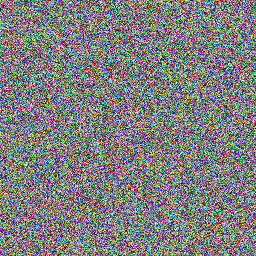

In [51]:
# display img
img

In [52]:
from PIL import Image

In [53]:
im = Image.open("Grace_Hopper.jpg")
print(im.format, im.size, im.mode)

JPEG (511, 599) RGB


In [54]:
im.show()

In [55]:
from torchvision.io import read_image

In [56]:
import os

In [57]:
DataPath = "/Users/me/Documents/Work/Dev/_data"
img1_d = read_image(os.path.join(DataPath, "imagenet-sample-images-master", "n01440764_tench.JPEG"))
print(img1_d.size())
img1 = T.ToPILImage()(img1_d)
print(img1.format, img1.size, img1.mode)

torch.Size([3, 375, 500])
None (500, 375) RGB


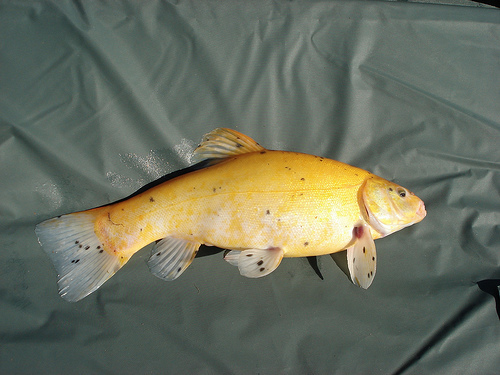

In [58]:
img1

In [59]:
4 in range(3)

False

In [60]:
mp1 = nn.MaxPool2d((3, 2), stride=(2, 1))
input = torch.randn(20, 16, 50, 32)
output = mp1(input)
output.size()

torch.Size([20, 16, 24, 31])

In [61]:
mp1.return_indices = True
output = mp1(input)
len(output)

2

In [62]:
l = ["a", "b", "c"]
for i, c in enumerate(l):
    print(i, c)

0 a
1 b
2 c


In [63]:
l[-3]

'a'

In [64]:
l.pop()

'c'

In [65]:
for i, c in zip(range(len(l)-1, -1, -1), reversed(l)):
    print(i, c)

1 b
0 a


In [66]:
for i, c in enumerate(reversed(l), start=1):
    print(len(l) - i, c)

1 b
0 a


In [67]:
l.pop()

'b'

In [68]:
l

['a']

In [69]:
t = torch.ones(1, 3, 5, 5)
for i in range(3):
    t[0, i] = t[0, i] * i
t

tensor([[[[0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.]],

         [[1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.]],

         [[2., 2., 2., 2., 2.],
          [2., 2., 2., 2., 2.],
          [2., 2., 2., 2., 2.],
          [2., 2., 2., 2., 2.],
          [2., 2., 2., 2., 2.]]]])

In [70]:
t[0, 2] = torch.ones(5, 5) * 10
t

tensor([[[[ 0.,  0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.,  0.]],

         [[ 1.,  1.,  1.,  1.,  1.],
          [ 1.,  1.,  1.,  1.,  1.],
          [ 1.,  1.,  1.,  1.,  1.],
          [ 1.,  1.,  1.,  1.,  1.],
          [ 1.,  1.,  1.,  1.,  1.]],

         [[10., 10., 10., 10., 10.],
          [10., 10., 10., 10., 10.],
          [10., 10., 10., 10., 10.],
          [10., 10., 10., 10., 10.],
          [10., 10., 10., 10., 10.]]]])

In [71]:
t.size(2)

5

In [72]:
x = torch.arange(12).view(1, 2, 2, 3)
x

tensor([[[[ 0,  1,  2],
          [ 3,  4,  5]],

         [[ 6,  7,  8],
          [ 9, 10, 11]]]])

In [73]:
torch.flip(x, [2, 3])

tensor([[[[ 5,  4,  3],
          [ 2,  1,  0]],

         [[11, 10,  9],
          [ 8,  7,  6]]]])

In [74]:
torch.transpose(x, 2, 3)

tensor([[[[ 0,  3],
          [ 1,  4],
          [ 2,  5]],

         [[ 6,  9],
          [ 7, 10],
          [ 8, 11]]]])

In [75]:
a = torch.randn(10, 5, 5)
a

tensor([[[-3.9090e-01, -1.4253e-01,  8.9974e-01, -2.0750e+00, -1.6365e+00],
         [ 1.0639e+00,  3.3427e-02, -2.2917e-02, -8.3100e-01,  4.9838e-01],
         [ 1.0120e+00,  1.4552e+00, -1.1598e+00,  7.0587e-01, -6.3234e-01],
         [ 4.8462e-01, -9.0953e-02,  4.3138e-01, -8.1141e-01, -1.0355e+00],
         [-3.1017e-01,  3.1266e-01,  8.1573e-01,  9.3756e-01, -1.1188e+00]],

        [[ 3.2355e-02,  3.7322e-02, -1.1515e+00,  7.3085e-02, -1.5315e+00],
         [-6.4368e-01, -1.1136e+00,  1.2967e+00,  5.3718e-01,  2.0518e-01],
         [-1.1667e+00,  1.2292e+00,  3.8693e-01,  6.2420e-01,  1.3670e+00],
         [ 4.3695e-01, -1.5541e+00,  3.4877e-01, -1.8174e+00,  3.1954e-02],
         [ 1.0725e+00,  5.5992e-01,  7.1524e-01, -2.7956e-01, -8.3639e-01]],

        [[-1.3905e+00,  3.0637e-02,  2.5615e+00,  2.4174e-01, -8.2301e-01],
         [-1.9221e+00, -2.8270e-01,  2.3081e-01,  1.3394e+00, -1.2487e+00],
         [ 6.2080e-01,  1.6582e+00, -3.6988e-02, -4.3634e-01,  7.0936e-01],
        

In [76]:
r = a.size(1)
idx_max = torch.argmax(a[0]).item()
print(a.max(dim=1), a[1, idx_max // r, idx_max % r])

torch.return_types.max(
values=tensor([[1.0639, 1.4552, 0.8997, 0.9376, 0.4984],
        [1.0725, 1.2292, 1.2967, 0.6242, 1.3670],
        [0.6208, 1.6582, 2.5615, 1.3394, 0.7094],
        [1.1178, 2.0564, 0.3994, 0.6631, 0.2648],
        [0.5825, 1.6295, 0.2582, 2.0563, 0.9442],
        [0.7093, 1.5822, 1.6556, 1.4939, 0.7481],
        [1.0236, 1.2797, 1.4616, 1.1976, 0.7130],
        [1.6289, 1.5667, 2.7607, 1.6211, 2.4978],
        [1.6692, 1.6593, 1.0046, 0.0949, 0.8980],
        [1.1066, 1.0574, 0.5084, 1.0126, 1.6947]]),
indices=tensor([[1, 2, 0, 4, 1],
        [4, 2, 1, 2, 2],
        [2, 2, 0, 1, 2],
        [1, 3, 0, 0, 0],
        [1, 0, 1, 3, 3],
        [4, 3, 4, 4, 2],
        [3, 0, 0, 2, 1],
        [4, 3, 4, 4, 3],
        [2, 3, 3, 0, 3],
        [0, 0, 1, 4, 4]])) tensor(1.2292)


In [77]:
torch.argmax(a, dim=0, keepdim=True)

tensor([[[9, 4, 2, 3, 4],
         [8, 8, 1, 2, 6],
         [8, 2, 7, 6, 1],
         [6, 3, 8, 4, 7],
         [7, 3, 7, 7, 9]]])

In [78]:
tuple = (1, 2)
tuple

(1, 2)

In [79]:
try:
    tuple[0] = 3
except TypeError as err:
    print("Handled error :", err)
tuple

Handled error : 'tuple' object does not support item assignment


(1, 2)

In [80]:
tuple_2_list = list(tuple)
try:
    tuple_2_list[0] = 3
except TypeError as err:
    print("Handled error :", err)
tuple_2_list

[3, 2]

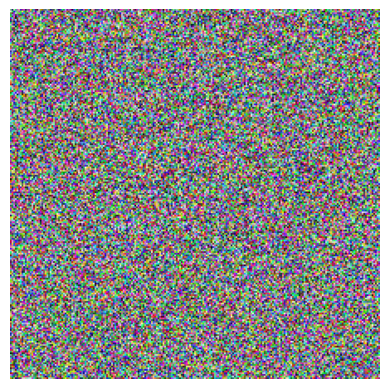

In [81]:
picture = np.random.rand(223, 223, 3) * 255
picture = picture.astype(np.uint8)
plt.imshow(picture)
plt.axis("off")
plt.show()

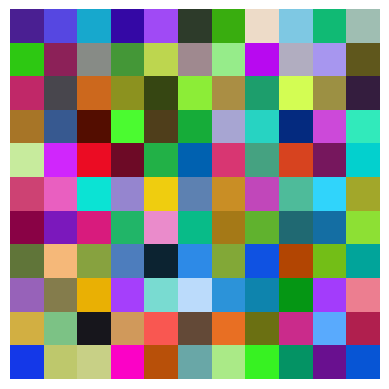

(11, 11, 3)


In [82]:
cropped = picture[62:73, 62:73, :]
plt.imshow(cropped)
plt.axis("off")
plt.show()
print(cropped.shape)

In [83]:
xx = torch.rand(5, 5)
print(xx)
xxx = xx.repeat(3, 1, 1)
print(xxx)

tensor([[0.4606, 0.8492, 0.0832, 0.8031, 0.2937],
        [0.3802, 0.6200, 0.8539, 0.8559, 0.5850],
        [0.9366, 0.7735, 0.3455, 0.6308, 0.2544],
        [0.8965, 0.2308, 0.4421, 0.7756, 0.6672],
        [0.5821, 0.9449, 0.6622, 0.1937, 0.8857]])
tensor([[[0.4606, 0.8492, 0.0832, 0.8031, 0.2937],
         [0.3802, 0.6200, 0.8539, 0.8559, 0.5850],
         [0.9366, 0.7735, 0.3455, 0.6308, 0.2544],
         [0.8965, 0.2308, 0.4421, 0.7756, 0.6672],
         [0.5821, 0.9449, 0.6622, 0.1937, 0.8857]],

        [[0.4606, 0.8492, 0.0832, 0.8031, 0.2937],
         [0.3802, 0.6200, 0.8539, 0.8559, 0.5850],
         [0.9366, 0.7735, 0.3455, 0.6308, 0.2544],
         [0.8965, 0.2308, 0.4421, 0.7756, 0.6672],
         [0.5821, 0.9449, 0.6622, 0.1937, 0.8857]],

        [[0.4606, 0.8492, 0.0832, 0.8031, 0.2937],
         [0.3802, 0.6200, 0.8539, 0.8559, 0.5850],
         [0.9366, 0.7735, 0.3455, 0.6308, 0.2544],
         [0.8965, 0.2308, 0.4421, 0.7756, 0.6672],
         [0.5821, 0.9449, 0.662

In [84]:
xx = torch.rand(3, 5, 5, 5)
xxx = xx[0]

In [85]:
xx[0].size()

torch.Size([5, 5, 5])

In [86]:
xxx = torch.unsqueeze(xx[0], 1).repeat(1, 3, 1, 1)
print(xxx.size())
xxx

torch.Size([5, 3, 5, 5])


tensor([[[[0.6382, 0.9938, 0.1555, 0.0135, 0.8342],
          [0.9801, 0.7015, 0.8058, 0.7146, 0.3038],
          [0.3561, 0.6070, 0.1648, 0.7923, 0.0917],
          [0.8327, 0.4680, 0.3191, 0.6436, 0.4276],
          [0.4676, 0.8422, 0.6569, 0.3641, 0.0715]],

         [[0.6382, 0.9938, 0.1555, 0.0135, 0.8342],
          [0.9801, 0.7015, 0.8058, 0.7146, 0.3038],
          [0.3561, 0.6070, 0.1648, 0.7923, 0.0917],
          [0.8327, 0.4680, 0.3191, 0.6436, 0.4276],
          [0.4676, 0.8422, 0.6569, 0.3641, 0.0715]],

         [[0.6382, 0.9938, 0.1555, 0.0135, 0.8342],
          [0.9801, 0.7015, 0.8058, 0.7146, 0.3038],
          [0.3561, 0.6070, 0.1648, 0.7923, 0.0917],
          [0.8327, 0.4680, 0.3191, 0.6436, 0.4276],
          [0.4676, 0.8422, 0.6569, 0.3641, 0.0715]]],


        [[[0.9888, 0.4701, 0.0055, 0.4502, 0.2079],
          [0.0928, 0.3598, 0.6462, 0.1223, 0.3439],
          [0.3844, 0.3358, 0.5043, 0.2868, 0.0890],
          [0.0371, 0.2216, 0.7000, 0.0614, 0.4678],
    

In [87]:
def transpose2d_output_size(
        input_size: int|Tuple[int, int],
        kernel_size: int|Tuple[int, int],
        padding_size: int|Tuple[int, int]=0,
        output_padding_size: int|Tuple[int, int]=0,
        stride_size: int|Tuple[int, int]=1,
        dilation_size: int|Tuple[int, int]=1
        ):
    _to_tuple = lambda v: (v, v)
    
    if type(input_size) == int:
        input_size = _to_tuple(input_size)
    elif type(input_size) == dict:
        input_size = (input_size["height"], input_size["width"])
    
    if type(kernel_size) == int:
        kernel_size = _to_tuple(kernel_size)
    
    if type(padding_size) == int:
        padding_size = _to_tuple(padding_size)
    
    if type(output_padding_size) == int:
        output_padding_size = _to_tuple(output_padding_size)

    if type(stride_size) == int:
        stride_size = _to_tuple(stride_size)
    
    if type(dilation_size) == int:
        dilation_size = _to_tuple(dilation_size)

    output_size = lambda i: \
        (input_size[i] - 1) * stride_size[i] - 2 * padding_size[i] + dilation_size[i] * (kernel_size[i] - 1) + output_padding_size[i] + 1
    output_size_h = output_size(0)
    output_size_w = output_size(1)
    return {"height": output_size_h, "width": output_size_w}

In [88]:
transpose2d_output_size(55, 11, 0, 4, 4)

{'height': 231, 'width': 231}

In [89]:
transpose2d_output_size(27, 5, 4, 4, 1)

{'height': 27, 'width': 27}

## Tests avec `dict`

### égalité entre deux dictionnaires

In [90]:
def f(a=1, b=2):
    print(a, b)
f()

1 2


In [91]:
args = {"a": 10, "b": 20}
f(**args)

10 20


In [92]:
args2 = {"b": 20, "a": 10}
args == args2

True

In [93]:
x = {'in_channels': 3, 'out_channels': 64, 'kernel_size': (7, 7), 'stride': (3, 3), 'padding': (2, 2), 'padding_mode': 'reflect', 'dilation': (2, 2), 'bias': None}
y = {'in_channels': 3, 'out_channels': 64, 'kernel_size': (7, 7), 'padding': (2, 2), 'stride': (3, 3), 'padding_mode': 'reflect', 'dilation': (2, 2), 'bias': None}
x == y

True

### Fusion

In [94]:
d1 = {"a": 1}
d2 = {"b": 2}
print(d1 | d2)

{'a': 1, 'b': 2}


### Tri

In [28]:
d = {1: "a", 2: "b", 3: "c"}
print(sorted(d, reverse=True))

[3, 2, 1]


## Tests pour nettoyer un tenseur

In [95]:
t = torch.arange(1, 21).view(2, -1)
v = 10
print(t==v)

tensor([[False, False, False, False, False, False, False, False, False,  True],
        [False, False, False, False, False, False, False, False, False, False]])


In [96]:
t * (t==v)

tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0, 10],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0]])

## Tests avec `None`

In [97]:
none = None
not_none = 1

print(none == not_none)
print(none == None)
print(none != None)
print(not_none != None)

False
True
False
True


In [98]:
tests = [(None, None), (10, None), (None, [1, 2]), (10, [1, 2])]
for value, pos in tests:
    print((value != None) and (pos != None))

False
False
False
True


In [99]:
v = None
print(v == None)
print(v == False)

v = False
print(v == None)
print(v == False)

True
False
False
True


## Tests avec `torch.tensor.size`

In [100]:
t1 = torch.arange(1, 21).view(2, -1)
t2 = torch.ones_like(t1)
t3 = torch.arange(1,5)

print(t1.size())
print(t2.size())
print(t1.size() == t2.size())
print(t1.size() == t3.size())

torch.Size([2, 10])
torch.Size([2, 10])
True
False


In [101]:
list(t1.size())

[2, 10]

In [130]:
t[0, 0].size()[0]

3

## Tests des listes en compréhension (`comprehensive list`)

Boucles imbriquées

In [102]:
[(a,b) for a in range(0,10) for b in range(10, 21)]

[(0, 10),
 (0, 11),
 (0, 12),
 (0, 13),
 (0, 14),
 (0, 15),
 (0, 16),
 (0, 17),
 (0, 18),
 (0, 19),
 (0, 20),
 (1, 10),
 (1, 11),
 (1, 12),
 (1, 13),
 (1, 14),
 (1, 15),
 (1, 16),
 (1, 17),
 (1, 18),
 (1, 19),
 (1, 20),
 (2, 10),
 (2, 11),
 (2, 12),
 (2, 13),
 (2, 14),
 (2, 15),
 (2, 16),
 (2, 17),
 (2, 18),
 (2, 19),
 (2, 20),
 (3, 10),
 (3, 11),
 (3, 12),
 (3, 13),
 (3, 14),
 (3, 15),
 (3, 16),
 (3, 17),
 (3, 18),
 (3, 19),
 (3, 20),
 (4, 10),
 (4, 11),
 (4, 12),
 (4, 13),
 (4, 14),
 (4, 15),
 (4, 16),
 (4, 17),
 (4, 18),
 (4, 19),
 (4, 20),
 (5, 10),
 (5, 11),
 (5, 12),
 (5, 13),
 (5, 14),
 (5, 15),
 (5, 16),
 (5, 17),
 (5, 18),
 (5, 19),
 (5, 20),
 (6, 10),
 (6, 11),
 (6, 12),
 (6, 13),
 (6, 14),
 (6, 15),
 (6, 16),
 (6, 17),
 (6, 18),
 (6, 19),
 (6, 20),
 (7, 10),
 (7, 11),
 (7, 12),
 (7, 13),
 (7, 14),
 (7, 15),
 (7, 16),
 (7, 17),
 (7, 18),
 (7, 19),
 (7, 20),
 (8, 10),
 (8, 11),
 (8, 12),
 (8, 13),
 (8, 14),
 (8, 15),
 (8, 16),
 (8, 17),
 (8, 18),
 (8, 19),
 (8, 20),
 (9, 10),


## Tests de `torch.unique`

In [103]:
t = torch.ones((10)).view(2, -1)
t[1, 3] = 10
print(torch.unique(t))

tensor([ 1., 10.])


## Tests de `torch.full`

In [104]:
print(torch.full((10,), 10))

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10])


## Tests de boucles

In [105]:
dim = -2
assert dim < 0, f"dim {dim} must be negative"
for i in range(-1, dim, -1):
    print(i)
print(">", dim)

-1
> -2


## Tests avec `torch.Tensor.max()`

In [131]:
torch.tensor([1, 2, 3]).max()

tensor(3)

## Tests avec `torch.Tensor.item()`

In [36]:
t = torch.arange(1, 11).view(-1, 1)
print(t)
print(t.ravel().tolist())

tensor([[ 1],
        [ 2],
        [ 3],
        [ 4],
        [ 5],
        [ 6],
        [ 7],
        [ 8],
        [ 9],
        [10]])
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


## Tests avec fonctions random

### Tests de `torch.randperm`

In [ ]:
t = torch.rand((1, 64, 55, 55))
idx = torch.randperm(t.shape[0])
t = t[idx].view(t.size())
print(t)

tensor([[[[0.9274, 0.6460, 0.4655,  ..., 0.2763, 0.0493, 0.0935],
          [0.3765, 0.2877, 0.2006,  ..., 0.3332, 0.9701, 0.5510],
          [0.9854, 0.2954, 0.3753,  ..., 0.5339, 0.7343, 0.3987],
          ...,
          [0.5073, 0.2197, 0.6471,  ..., 0.1723, 0.4815, 0.0338],
          [0.0077, 0.8587, 0.5213,  ..., 0.3459, 0.1529, 0.4065],
          [0.7393, 0.4143, 0.1030,  ..., 0.3649, 0.4709, 0.8956]],

         [[0.7732, 0.8546, 0.6309,  ..., 0.1449, 0.3011, 0.4865],
          [0.1985, 0.3551, 0.8648,  ..., 0.4074, 0.5405, 0.3825],
          [0.9264, 0.3285, 0.5766,  ..., 0.2249, 0.8274, 0.0163],
          ...,
          [0.1439, 0.7610, 0.9723,  ..., 0.6306, 0.0452, 0.6068],
          [0.5981, 0.1021, 0.5468,  ..., 0.0298, 0.9839, 0.9728],
          [0.4630, 0.5661, 0.9126,  ..., 0.2480, 0.5620, 0.1836]],

         [[0.6898, 0.4921, 0.6022,  ..., 0.1859, 0.7111, 0.1115],
          [0.0069, 0.3011, 0.3451,  ..., 0.7697, 0.2765, 0.5621],
          [0.1888, 0.7274, 0.2694,  ..., 0

### Tests de `torch.randint`

In [7]:
size = b, c, h, w = (2, 3, 2, 5)
n = reduce(lambda x,y : x*y, size)
t = torch.arange(0, n).view(size)
t

tensor([[[[ 0,  1,  2,  3,  4],
          [ 5,  6,  7,  8,  9]],

         [[10, 11, 12, 13, 14],
          [15, 16, 17, 18, 19]],

         [[20, 21, 22, 23, 24],
          [25, 26, 27, 28, 29]]],


        [[[30, 31, 32, 33, 34],
          [35, 36, 37, 38, 39]],

         [[40, 41, 42, 43, 44],
          [45, 46, 47, 48, 49]],

         [[50, 51, 52, 53, 54],
          [55, 56, 57, 58, 59]]]])

In [14]:
i = torch.randint(0, h, (b, c, 1))
print(i)
print(t[i])

tensor([[[1],
         [1],
         [1]],

        [[1],
         [0],
         [0]]])
tensor([[[[[[30, 31, 32, 33, 34],
            [35, 36, 37, 38, 39]],

           [[40, 41, 42, 43, 44],
            [45, 46, 47, 48, 49]],

           [[50, 51, 52, 53, 54],
            [55, 56, 57, 58, 59]]]],



         [[[[30, 31, 32, 33, 34],
            [35, 36, 37, 38, 39]],

           [[40, 41, 42, 43, 44],
            [45, 46, 47, 48, 49]],

           [[50, 51, 52, 53, 54],
            [55, 56, 57, 58, 59]]]],



         [[[[30, 31, 32, 33, 34],
            [35, 36, 37, 38, 39]],

           [[40, 41, 42, 43, 44],
            [45, 46, 47, 48, 49]],

           [[50, 51, 52, 53, 54],
            [55, 56, 57, 58, 59]]]]],




        [[[[[30, 31, 32, 33, 34],
            [35, 36, 37, 38, 39]],

           [[40, 41, 42, 43, 44],
            [45, 46, 47, 48, 49]],

           [[50, 51, 52, 53, 54],
            [55, 56, 57, 58, 59]]]],



         [[[[ 0,  1,  2,  3,  4],
            [ 5,  6,

## Proto pour récupérer le max selon la dimension dans la bonne forme (dont création d'un masque), et leur position dans le tenseur

In [106]:
b = 2
c = 2
h = 3
w = 3
t = torch.randperm(b*c*h*w).view(b, c, h, w)

In [107]:
print(t.size(), t, sep="\n")

torch.Size([2, 2, 3, 3])
tensor([[[[13, 31, 30],
          [21, 17,  2],
          [20, 19, 24]],

         [[14, 32, 16],
          [11, 23, 10],
          [29, 34, 35]]],


        [[[28,  7, 15],
          [26,  3, 25],
          [ 4, 12,  5]],

         [[22,  6,  8],
          [ 9, 18,  1],
          [ 0, 27, 33]]]])


In [108]:
r_max, _ = torch.max(t, dim=-1, keepdim=True)
print(r_max.size(), r_max, sep="\n")

torch.Size([2, 2, 3, 1])
tensor([[[[31],
          [21],
          [24]],

         [[32],
          [23],
          [35]]],


        [[[28],
          [26],
          [12]],

         [[22],
          [18],
          [33]]]])


In [109]:
print(t.size(), t, sep="\n")

torch.Size([2, 2, 3, 3])
tensor([[[[13, 31, 30],
          [21, 17,  2],
          [20, 19, 24]],

         [[14, 32, 16],
          [11, 23, 10],
          [29, 34, 35]]],


        [[[28,  7, 15],
          [26,  3, 25],
          [ 4, 12,  5]],

         [[22,  6,  8],
          [ 9, 18,  1],
          [ 0, 27, 33]]]])


In [110]:
r_max, _ = torch.max(t, dim=-1, keepdim=False)
print(r_max.size(), r_max, sep="\n")

torch.Size([2, 2, 3])
tensor([[[31, 21, 24],
         [32, 23, 35]],

        [[28, 26, 12],
         [22, 18, 33]]])


In [111]:
print(t.size(), t, sep="\n")

torch.Size([2, 2, 3, 3])
tensor([[[[13, 31, 30],
          [21, 17,  2],
          [20, 19, 24]],

         [[14, 32, 16],
          [11, 23, 10],
          [29, 34, 35]]],


        [[[28,  7, 15],
          [26,  3, 25],
          [ 4, 12,  5]],

         [[22,  6,  8],
          [ 9, 18,  1],
          [ 0, 27, 33]]]])


In [126]:
def get_max_by_dim(
          tensor:torch.tensor,
          dim:int = -1, 
          return_pos:bool = False,
          keepdim:bool = False
          ) -> torch.tensor|Tuple[torch.tensor, torch.tensor]:
    """
        Return tensor containing max at dim, resized or with same size,
        and if required positions in provided tensor
    """
    assert -len(tensor.size()) <= dim and dim < 0, f"dim must be in range [-{len(tensor.size())}, -1]"

    def multi_right_unsqeeze(t, diff_size):
        return t.view(list(t.size()) + [1] * diff_size)
    
    max_vector = tensor
    for _ in range(-1, dim-1, -1):
        max_vector, _ = torch.max(max_vector, dim=-1, keepdim=False)
    
    if len(max_vector.size()) == 0:
            max_vector = max_vector[None]
    elif keepdim:
        max_vector = multi_right_unsqeeze(max_vector, abs(dim))

    if return_pos:
        if keepdim:
            max_vector_resized = max_vector
        else :
            max_vector_resized = multi_right_unsqeeze(max_vector, abs(dim))
        pos = (tensor == max_vector_resized).nonzero(as_tuple=False)
        return max_vector, pos
    else:
        return max_vector

In [127]:
max_vector, pos = get_max_by_dim(t, dim=-1, return_pos=True)
print(max_vector.size(), max_vector, sep="\n")
print(pos)

max_vector_b = max_vector.unsqueeze(dim=-1).repeat(1, 1, 1, t.size(-1))
#print(max_vector_b)
#print(t == max_vector_b)

print(list(max_vector.size()) + [1])
max_vector_c = max_vector.view(list(max_vector.size()) + [1])
print(max_vector_c.size())

print(t * (t == max_vector_c))


torch.Size([2, 2, 3])
tensor([[[31, 21, 24],
         [32, 23, 35]],

        [[28, 26, 12],
         [22, 18, 33]]])
tensor([[0, 0, 0, 1],
        [0, 0, 1, 0],
        [0, 0, 2, 2],
        [0, 1, 0, 1],
        [0, 1, 1, 1],
        [0, 1, 2, 2],
        [1, 0, 0, 0],
        [1, 0, 1, 0],
        [1, 0, 2, 1],
        [1, 1, 0, 0],
        [1, 1, 1, 1],
        [1, 1, 2, 2]])
[2, 2, 3, 1]
torch.Size([2, 2, 3, 1])
tensor([[[[ 0, 31,  0],
          [21,  0,  0],
          [ 0,  0, 24]],

         [[ 0, 32,  0],
          [ 0, 23,  0],
          [ 0,  0, 35]]],


        [[[28,  0,  0],
          [26,  0,  0],
          [ 0, 12,  0]],

         [[22,  0,  0],
          [ 0, 18,  0],
          [ 0,  0, 33]]]])


In [128]:
max_vector, pos = get_max_by_dim(t, dim=-1, return_pos=True, keepdim=True)
print(max_vector.size(), max_vector, sep="\n")

torch.Size([2, 2, 3, 1])
tensor([[[[31],
          [21],
          [24]],

         [[32],
          [23],
          [35]]],


        [[[28],
          [26],
          [12]],

         [[22],
          [18],
          [33]]]])


In [129]:
max_vector, pos = get_max_by_dim(t, dim=-2, return_pos=True)
print(max_vector.size(), max_vector, sep="\n")
print(pos)

max_vector = max_vector.unsqueeze(dim=-1).unsqueeze(dim=-1).repeat(1, 1, t.size(-2), t.size(-1))
max_vector
print(t == max_vector)

torch.Size([2, 2])
tensor([[31, 35],
        [28, 33]])
tensor([[0, 0, 0, 1],
        [0, 1, 2, 2],
        [1, 0, 0, 0],
        [1, 1, 2, 2]])
tensor([[[[False,  True, False],
          [False, False, False],
          [False, False, False]],

         [[False, False, False],
          [False, False, False],
          [False, False,  True]]],


        [[[ True, False, False],
          [False, False, False],
          [False, False, False]],

         [[False, False, False],
          [False, False, False],
          [False, False,  True]]]])


In [115]:
max_vector, pos = get_max_by_dim(t, dim=-3, return_pos=True)
print(max_vector.size(), max_vector, sep="\n")
print(pos)

torch.Size([2])
tensor([35, 33])
tensor([[0, 1, 2, 2],
        [1, 1, 2, 2]])


In [116]:
max_vector, pos = get_max_by_dim(t, dim=-4, return_pos=True)
print(max_vector.size(), max_vector, sep="\n")
print(pos)

max_vector = get_max_by_dim(t, dim=-4, return_pos=False)
print(max_vector.size(), max_vector, sep="\n")

torch.Size([1])
tensor([35])
tensor([[0, 0, 1, 2, 2]])
torch.Size([1])
tensor([35])


In [121]:
max_vector, pos = get_max_by_dim(t[0,0,0], dim=-1, return_pos=True, keepdim=False)
print(max_vector.size(), max_vector, sep="\n")
print(pos)

torch.Size([1])
tensor([31])
tensor([[0, 1]])


In [123]:
max_vector, pos = get_max_by_dim(t[0,0,0], dim=-1, return_pos=True, keepdim=True)
print(t[0,0,0].size())
print(max_vector.size(), max_vector, sep="\n")
print(pos)

torch.Size([3])
torch.Size([1, 1])
tensor([[31]])
tensor([[0, 1]])


## Proto pour récupérer les indices des premières occurrences de valeurs fournies, dans différents cas de figure

In [218]:
size = [b, c, h, w] = [2, 3, 2, 5]

n = reduce(lambda x,y : x*y, size[2:])
t_4d_r = torch.arange(0, n).view(1, 1, h, w).repeat(2, 3, 1, 1)
t_4d_r[:, :, 1, 3] = 1
print("> t_4d_r")
print(t_4d_r.size(), t_4d_r, sep="\n")

t_3d_r = t_4d_r[0]
print("> t_3d_r")
print(t_3d_r.size(), t_3d_r, sep="\n")

print("> t_4d_d")
n = reduce(lambda x,y : x*y, size)
t_4d_d = torch.arange(0, n).view(size)
print(t_4d_d.size(), t_4d_d, sep="\n")

t_3d_d = t_4d_d[0]
print("> t_3d_d")
print(t_3d_d.size(), t_3d_d, sep="\n")

> t_4d_r
torch.Size([2, 3, 2, 5])
tensor([[[[0, 1, 2, 3, 4],
          [5, 6, 7, 1, 9]],

         [[0, 1, 2, 3, 4],
          [5, 6, 7, 1, 9]],

         [[0, 1, 2, 3, 4],
          [5, 6, 7, 1, 9]]],


        [[[0, 1, 2, 3, 4],
          [5, 6, 7, 1, 9]],

         [[0, 1, 2, 3, 4],
          [5, 6, 7, 1, 9]],

         [[0, 1, 2, 3, 4],
          [5, 6, 7, 1, 9]]]])
> t_3d_r
torch.Size([3, 2, 5])
tensor([[[0, 1, 2, 3, 4],
         [5, 6, 7, 1, 9]],

        [[0, 1, 2, 3, 4],
         [5, 6, 7, 1, 9]],

        [[0, 1, 2, 3, 4],
         [5, 6, 7, 1, 9]]])
> t_4d_d
torch.Size([2, 3, 2, 5])
tensor([[[[ 0,  1,  2,  3,  4],
          [ 5,  6,  7,  8,  9]],

         [[10, 11, 12, 13, 14],
          [15, 16, 17, 18, 19]],

         [[20, 21, 22, 23, 24],
          [25, 26, 27, 28, 29]]],


        [[[30, 31, 32, 33, 34],
          [35, 36, 37, 38, 39]],

         [[40, 41, 42, 43, 44],
          [45, 46, 47, 48, 49]],

         [[50, 51, 52, 53, 54],
          [55, 56, 57, 58, 59]]]])
>

In [180]:
values = torch.tensor([3])
pos = (t_4d_r == values).nonzero()
print(pos)

print("-"*30)
repeat = [b, 1, 1, 1]
values = torch.tensor([3]).view(1, 1, 1, 1).repeat(repeat)
print(values.size())
pos = (t_4d_r == values).nonzero()
print(pos)

print("-"*30)
repeat = [1, 1, 1, 1]
values = torch.tensor([2, 8]).view(b, 1, 1, 1).repeat(repeat)
print(values.size())
pos = (t_4d_r == values).nonzero()
print(pos)

print("-"*30)
repeat = [1, c, 1, 1]
values = torch.tensor([3]).view(1, 1, 1, 1).repeat(repeat)
print(values.size())
pos = (t_4d_r == values).nonzero()
print(pos)

print("-"*30)
repeat = [b, c, 1, 1]
values = torch.tensor([3]).view(1, 1, 1, 1).repeat(repeat)
print(values.size())
pos = (t_4d_r == values).nonzero()
print(pos)

print("-"*30)
repeat = [1, 1, h, 1]
values = torch.tensor([3]).view(1, 1, 1, 1).repeat(repeat)
print(values.size())
pos = (t_4d_r == values).nonzero()
print(pos)

print("-"*30)
repeat = [1, c, h, 1]
values = torch.tensor([3]).view(1, 1, 1, 1).repeat(repeat)
print(values.size())
pos = (t_4d_r == values).nonzero()
print(pos)

print("-"*30)
repeat = [b, c, h, 1]
values = torch.tensor([3]).view(1, 1, 1, 1).repeat(repeat)
print(values.size())
pos = (t_4d_r == values).nonzero()
print(pos)



tensor([[0, 0, 0, 3],
        [0, 1, 0, 3],
        [0, 2, 0, 3],
        [1, 0, 0, 3],
        [1, 1, 0, 3],
        [1, 2, 0, 3]])
------------------------------
torch.Size([2, 1, 1, 1])
tensor([[0, 0, 0, 3],
        [0, 1, 0, 3],
        [0, 2, 0, 3],
        [1, 0, 0, 3],
        [1, 1, 0, 3],
        [1, 2, 0, 3]])
------------------------------
torch.Size([2, 1, 1, 1])
tensor([[0, 0, 0, 2],
        [0, 1, 0, 2],
        [0, 2, 0, 2],
        [1, 0, 1, 3],
        [1, 1, 1, 3],
        [1, 2, 1, 3]])
------------------------------
torch.Size([1, 3, 1, 1])
tensor([[0, 0, 0, 3],
        [0, 1, 0, 3],
        [0, 2, 0, 3],
        [1, 0, 0, 3],
        [1, 1, 0, 3],
        [1, 2, 0, 3]])
------------------------------
torch.Size([2, 3, 1, 1])
tensor([[0, 0, 0, 3],
        [0, 1, 0, 3],
        [0, 2, 0, 3],
        [1, 0, 0, 3],
        [1, 1, 0, 3],
        [1, 2, 0, 3]])
------------------------------
torch.Size([1, 1, 2, 1])
tensor([[0, 0, 0, 3],
        [0, 1, 0, 3],
        [0,

In [144]:
p = (pos[:, 1:3] == torch.tensor([1, 0])).all(dim=1)
pos[p]

tensor([[0, 1, 0, 3],
        [1, 1, 0, 3]])

In [174]:
torch.tensor([ True, False, False, False, False, False]).any(dim=0)

tensor(True)

In [203]:
print(values.flatten())
#print(pos)

def get_first_occurrence_indices(tensor:torch.tensor, values:torch.tensor) -> torch.Tensor:
    """
    Return the indices of first occurrence of each values, regarding the shape of values tensor :
    if tensor shape is (b, c, h, w), then if provided values shape is :
        (1),            -> 1 occurrence sur l'ensemble de d1
        (1, 1, 1, 1),   -> 1 occurrence sur l'ensemble de d1
        (b, 1, 1, 1),   -> 1 occurrence par item de d1 (<= card(d1))
        (1, c, 1, 1),   -> 1 occurrence par item de d2 par item de d1 (<= card(d1) * card(d2))
            pattern values repeated on d1
        (b, c, 1, 1),   -> 1 occurrence par item de d2 par item de d1 (<= card(d1)*card(d2))
        (1, 1, h, 1),   -> 1 occurrence par item de d3 par item de d2 par item de d1 (<= card(d1) * card(d2) * card(d3))
            pattern values repeated on d1 and d2
        (b, 1, h, 1),   -> 1 occurrence par item de d3 par item de d2 par item de d1 (<= card(d1) * card(d2) * card(d3))
            pattern values repeated on d2 for each d1
        (b, c, h, 1)    -> 1 occurrence par item de d3 par item de d2 par item de d1 (<= card(d1) * card(d2) * card(d3))
    """
    # détection des valeurs recherchées dans les dimensions corresondantes selon la forme de values
    pos = (tensor == values).nonzero()

    # squeezing by right as long as possible
    v_size = list(values.size())
    while len(v_size) > 1 and v_size[-1] == 1:
        v_size.pop()

    # finding first occurrence positions
    len_v_size = len(v_size)
    t_size = tensor.size()[:len_v_size]
    indices = torch.zeros((len_v_size,), dtype=int)
    first_occ_pos = []
    # for each possible indices regarding dimensions of tensor
    while indices[0] < t_size[0]:
        print("indices", indices)
        # search pos starting with indices
        eligible_pos = (pos[:, :len_v_size] == indices).all(dim=1)
        #pos_eligible_pos = eligible_pos.nonzero(as_tuple=False)
        #print(eligible_pos)
        #print(eligible_pos.any())
        if eligible_pos.any():
            first_occ_pos.append(pos[eligible_pos][0].tolist())
        # get first occurrence position
        #print(pos_eligible_pos)
        #if (len(pos_eligible_pos)):
        #    first_occ_pos.append(pos[*pos_eligible_pos[0]].tolist())
        # increment indices
        d = -1
        while d < 0:
            indices[d] += 1
            if indices[d] == t_size[d] and d > -len_v_size:
                indices[d] = 0
                d -= 1
            else:
                d = 0
    #print(first_occ_pos)
    if len_v_size == 1 and v_size[0] == 1:
        return torch.tensor(first_occ_pos[:1])
    else:
        return torch.tensor(first_occ_pos)

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


In [204]:
values = torch.tensor([1]).view(1, 1, 1, 1).repeat(b, c, h, 1)
pos_first_occ = get_first_occurrence_indices(t_4d_r, values)
print(pos_first_occ)
print(t_4d_r[*pos_first_occ.T])

indices tensor([0, 0, 0])
indices tensor([0, 0, 1])
indices tensor([0, 1, 0])
indices tensor([0, 1, 1])
indices tensor([0, 2, 0])
indices tensor([0, 2, 1])
indices tensor([1, 0, 0])
indices tensor([1, 0, 1])
indices tensor([1, 1, 0])
indices tensor([1, 1, 1])
indices tensor([1, 2, 0])
indices tensor([1, 2, 1])
tensor([[0, 0, 0, 1],
        [0, 0, 1, 3],
        [0, 1, 0, 1],
        [0, 1, 1, 3],
        [0, 2, 0, 1],
        [0, 2, 1, 3],
        [1, 0, 0, 1],
        [1, 0, 1, 3],
        [1, 1, 0, 1],
        [1, 1, 1, 3],
        [1, 2, 0, 1],
        [1, 2, 1, 3]])
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


In [224]:
tests = [
    { # 1
        "tensor": t_3d_r,
        "values": torch.tensor([1]),
        "expected": torch.tensor([1])
    },

     { #
        "tensor": t_3d_r,
        "values": torch.tensor([1]).view(1, 1, 1).repeat(c, 1, 1),
        "expected": torch.tensor([1]).repeat(c)
    },
    { #
        "tensor": t_3d_d,
        "values": torch.tensor([1]).view(1, 1, 1).repeat(c, 1, 1),
        "expected": torch.tensor([1])
    },
     { #
        "tensor": t_3d_r,
        "values": torch.tensor([1]).view(1, 1, 1).repeat(c, h, 1),
        "expected": torch.tensor([1]).repeat(c*h)
    },
    { #
        "tensor": t_3d_d,
        "values": torch.tensor([1]).view(1, 1, 1).repeat(c, h, 1),
        "expected": torch.tensor([1])
    },

    { #
        "tensor": t_3d_r,
        "values": torch.tensor([1, 7, 9]).view(c, 1, 1),
        "expected": torch.tensor([1, 7, 9])
    },
    { #
        "tensor": t_3d_d,
        "values": torch.tensor([7, 17, 28]).view(c, 1, 1),
        "expected": torch.tensor([7, 17, 28])
    },

    { #
        "tensor": t_3d_r,
        "values": torch.tensor([1, 6]).view(1, h, 1).repeat(c, 1, 1),
        "expected": torch.tensor([1, 6]).repeat(3)
    },
    { #
        "tensor": t_3d_d,
        "values": torch.tensor([2, 7, 12, 16, 23, 28]).view(c, h, 1),
        "expected": torch.tensor([2, 7, 12, 16, 23, 28])
    },

    { # 1
        "tensor": t_4d_r,
        "values": torch.tensor([1]),
        "expected": torch.tensor([1])
    },

    { #
        "tensor": t_4d_r,
        "values": torch.tensor([1]).view(1, 1, 1, 1).repeat(b, 1, 1, 1),
        "expected": torch.tensor([1]).repeat(b)
    },
    { #
        "tensor": t_4d_d,
        "values": torch.tensor([1]).view(1, 1, 1, 1).repeat(b, 1, 1, 1),
        "expected": torch.tensor([1])
    },
    { #
        "tensor": t_4d_r,
        "values": torch.tensor([1]).view(1, 1, 1, 1).repeat(b, c, 1, 1),
        "expected": torch.tensor([1]).repeat(b*c)
    },
    { #
        "tensor": t_4d_d,
        "values": torch.tensor([1]).view(1, 1, 1, 1).repeat(b, c, 1, 1),
        "expected": torch.tensor([1])
    },
    { #
        "tensor": t_4d_r,
        "values": torch.tensor([1]).view(1, 1, 1, 1).repeat(b, c, h, 1),
        "expected": torch.tensor([1]).repeat(b*c*h)
    },
    { #
        "tensor": t_4d_d,
        "values": torch.tensor([1]).view(1, 1, 1, 1).repeat(b, c, h, 1),
        "expected": torch.tensor([1])
    },

    { #
        "tensor": t_4d_r,
        "values": torch.tensor([1, 7]).view(b, 1, 1, 1),
        "expected": torch.tensor([1, 7])
    },
    { #
        "tensor": t_4d_d,
        "values": torch.tensor([7, 37]).view(b, 1, 1, 1),
        "expected": torch.tensor([7, 37])
    },

    { #
        "tensor": t_4d_r,
        "values": torch.tensor([1, 6, 9]).view(1, c, 1, 1).repeat(b, 1, 1, 1),
        "expected": torch.tensor([1, 6, 9, 1, 6, 9])
    },
    { #
        "tensor": t_4d_d,
        "values": torch.tensor([7, 12, 23, 37, 46, 55]).view(b, c, 1, 1),
        "expected": torch.tensor([7, 12, 23, 37, 46, 55])
    },
    { #
        "tensor": t_4d_d,
        "values": torch.tensor([2, 7, 12, 16, 23, 28, 31, 37, 40, 46, 54, 55]).view(b, c, h, 1),
        "expected": torch.tensor([2, 7, 12, 16, 23, 28, 31, 37, 40, 46, 54, 55])
    },
]

for i, test in enumerate(tests, start=1):
    print(f"=== Test #{i}")
    print("> tensor :", test["tensor"].size(), sep="\n")
    result = get_first_occurrence_indices(test["tensor"], test["values"])
    print("> result :", result, sep="\n")
    check = test["tensor"][*result.T]
    print("> check :", check, sep="\n")
    assert torch.equal(test["expected"], check), f"Test #{i} : Error {test['expected']}"
    print()

print("OK !!!")

=== Test #1
> tensor :
torch.Size([3, 2, 5])
indices tensor([0])
indices tensor([1])
indices tensor([2])
> result :
tensor([[0, 0, 1]])
> check :
tensor([1])

=== Test #2
> tensor :
torch.Size([3, 2, 5])
indices tensor([0])
indices tensor([1])
indices tensor([2])
> result :
tensor([[0, 0, 1],
        [1, 0, 1],
        [2, 0, 1]])
> check :
tensor([1, 1, 1])

=== Test #3
> tensor :
torch.Size([3, 2, 5])
indices tensor([0])
indices tensor([1])
indices tensor([2])
> result :
tensor([[0, 0, 1]])
> check :
tensor([1])

=== Test #4
> tensor :
torch.Size([3, 2, 5])
indices tensor([0, 0])
indices tensor([0, 1])
indices tensor([1, 0])
indices tensor([1, 1])
indices tensor([2, 0])
indices tensor([2, 1])
> result :
tensor([[0, 0, 1],
        [0, 1, 3],
        [1, 0, 1],
        [1, 1, 3],
        [2, 0, 1],
        [2, 1, 3]])
> check :
tensor([1, 1, 1, 1, 1, 1])

=== Test #5
> tensor :
torch.Size([3, 2, 5])
indices tensor([0, 0])
indices tensor([0, 1])
indices tensor([1, 0])
indices tensor([1,

## Proto pour rendre coherent à l'unpooling

In [25]:
tests = [
    { # no batch
        "tensor": torch.tensor([
            [
                [36,  0, 17, 18],
                [ 0,  0,  0,  0],
                [20,  0, 22,  0],
                [26,  0,  0, 28]
            ]
        ]),
        "pool_indices": torch.tensor([
            [
                [ 6,  6,  7,  8],
                [ 6,  6,  7,  8],
                [10, 11, 12, 13],
                [16, 16, 17, 18]
            ]
        ]),
        "expected": torch.tensor([
            [
                [36, 36, 17, 18],
                [36, 36, 17, 18],
                [20,  0, 22,  0],
                [26, 26,  0, 28]
            ]
        ])
    },
    { # batch
            "tensor": torch.tensor([
                [[
                    [36,  0, 17, 18],
                    [ 0,  0,  0,  0],
                    [20,  0, 22,  0],
                    [26,  0,  0, 28]
                ]],
                [[
                    [35,  0, 17,  0],
                    [ 0,  0,  0, 18],
                    [20,  0, 22,  0],
                    [26,  0,  0, 28]
                ]]
            ]),
            "pool_indices": torch.tensor([
                [[
                    [ 6,  6,  7,  8],
                    [ 6,  6,  7,  8],
                    [10, 11, 12, 13],
                    [16, 16, 17, 18]
                ]],
                [[
                    [ 6,  6,  7,  8],
                    [ 6,  6,  7,  8],
                    [10, 11, 12, 13],
                    [16, 16, 17, 18]
                ]]
            ]),
            "expected": torch.tensor([
                [[
                    [36, 36, 17, 18],
                    [36, 36, 17, 18],
                    [20,  0, 22,  0],
                    [26, 26,  0, 28]
                ]],
                [[
                    [35, 35, 17, 18],
                    [35, 35, 17, 18],
                    [20,  0, 22,  0],
                    [26, 26,  0, 28]
                ]]
            ])
        }
]

In [30]:
tensor, pool_indices, expected = tests[0].values()
print(">tensor", tensor.size(), tensor, sep="\n")
print(">pool_indices", pool_indices.size(), pool_indices, sep="\n")
V_nz = tensor != 0
I_nz = pool_indices * V_nz
print(">I_nz", I_nz, sep="\n")
Unique = I_nz.unique()[1:]
print(">Unique", Unique, sep="\n")
print("pool_indices.view(-1, 1)", pool_indices.view(-1, 1))
Mask = pool_indices.view(-1, 1) == Unique
print(">Mask", Mask, sep="\n")
Mask = Mask.view(pool_indices.size())
print(">Mask", Mask, sep="\n")

>tensor
torch.Size([1, 4, 4])
tensor([[[36,  0, 17, 18],
         [ 0,  0,  0,  0],
         [20,  0, 22,  0],
         [26,  0,  0, 28]]])
>pool_indices
torch.Size([1, 4, 4])
tensor([[[ 6,  6,  7,  8],
         [ 6,  6,  7,  8],
         [10, 11, 12, 13],
         [16, 16, 17, 18]]])
>I_nz
tensor([[[ 6,  0,  7,  8],
         [ 0,  0,  0,  0],
         [10,  0, 12,  0],
         [16,  0,  0, 18]]])
>Unique
tensor([ 6,  7,  8, 10, 12, 16, 18])
pool_indices.view(-1, 1) tensor([[ 6],
        [ 6],
        [ 7],
        [ 8],
        [ 6],
        [ 6],
        [ 7],
        [ 8],
        [10],
        [11],
        [12],
        [13],
        [16],
        [16],
        [17],
        [18]])
>Mask
tensor([[ True, False, False, False, False, False, False],
        [ True, False, False, False, False, False, False],
        [False,  True, False, False, False, False, False],
        [False, False,  True, False, False, False, False],
        [ True, False, False, False, False, False, False],
  

RuntimeError: shape '[1, 4, 4]' is invalid for input of size 112

## Lecture d'un fichier de données

In [14]:
def read_imagenet_classes(file_path):
    with open(file_path, 'r') as f:
        class_ids = [int(line.strip()) for line in f if line.strip().isdigit()]
    return class_ids

# Exemple d'utilisation
file_path = "ILSVRC2012_validation_ground_truth.txt"
imagenet_classes = read_imagenet_classes(file_path)
print(imagenet_classes)

[490, 361, 171, 822, 297, 482, 13, 704, 599, 164, 649, 11, 73, 286, 554, 6, 648, 399, 749, 545, 13, 204, 318, 693, 399, 304, 102, 207, 480, 780, 644, 275, 14, 954, 249, 790, 501, 547, 809, 606, 297, 927, 424, 156, 60, 983, 256, 207, 281, 456, 413, 498, 561, 750, 182, 267, 118, 893, 597, 840, 836, 107, 647, 471, 945, 451, 214, 790, 291, 837, 707, 193, 397, 568, 401, 705, 200, 202, 31, 949, 361, 98, 709, 483, 563, 695, 122, 497, 914, 476, 102, 199, 104, 221, 138, 257, 188, 436, 229, 52, 377, 200, 597, 544, 131, 935, 602, 342, 508, 748, 617, 901, 184, 513, 204, 999, 782, 922, 869, 598, 596, 701, 970, 452, 631, 817, 57, 398, 885, 10, 288, 305, 34, 112, 273, 120, 959, 657, 823, 356, 32, 657, 753, 372, 364, 349, 106, 513, 551, 366, 228, 917, 464, 655, 737, 58, 62, 219, 832, 922, 192, 303, 946, 996, 737, 333, 729, 824, 517, 89, 724, 2, 829, 172, 266, 123, 434, 149, 39, 171, 44, 662, 734, 782, 270, 153, 283, 58, 217, 581, 170, 306, 689, 753, 613, 454, 885, 392, 316, 956, 527, 817, 47, 223, 516

## Une valeur dans une ligne de tenseur

In [19]:
t1 = torch.arange(1, 10).reshape(3, 3)
print(t1)
t2 = torch.tensor([2, -1, 7]).reshape(3, 1)
print(t2)

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])
tensor([[ 2],
        [-1],
        [ 7]])


In [21]:
t3 = t1 - t2
print(t3)

tensor([[-1,  0,  1],
        [ 5,  6,  7],
        [ 0,  1,  2]])


In [26]:
t4 = t3 == 0
print(t4)

tensor([[False,  True, False],
        [False, False, False],
        [ True, False, False]])


In [27]:
t4.sum()

tensor(2)